# EIP-8038 State Access Params Analysis

Analyze the estimated new gas values from `new_gas_all_params.csv` (benchmarkoor, 2026-03-01 to 2026-03-12).

**Questions:**
1. How do different tests and variants (cache strategy, account mode, existing slots) impact the new gas for each parameter?
2. Do different clients show different behavior across tests and variants?

In [25]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [26]:
sns.set_theme(
    style="whitegrid", palette="Set2", rc={"figure.dpi": 150, "axes.titlesize": 13}
)

repo_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
src_dir = os.path.join(repo_dir, "src")
sys.path.append(src_dir)

In [27]:
from nnls import fit_NNLS_without_low_diff_runs

## 1. Process data and do quick EDA

In [28]:
# Load data
data_dir = os.path.join(
    repo_dir,
    "reports",
    "eip-8038",
    "runtime_estimation",
    "2026-03-01_2026-03-22_benchmarkoor",
)
df = pd.read_csv(os.path.join(data_dir, "new_gas_all_params.csv"))

# Fill NaN variants with descriptive labels
df["cache_strategy"] = df["cache_strategy"].fillna("N/A")
df["account_mode"] = df["account_mode"].fillna("N/A")
df["existing_slots"] = (
    df["existing_slots"]
    .map({True: "existing", False: "new", None: "N/A"})
    .fillna("N/A")
)

# Short test names and params for readability
df["test_short"] = (
    df["test_name"].str.replace("test_", "").str.replace("_benchmark", "")
)
df["gas_param_short"] = df["gas_param"].str.replace("GAS_", "")

# Combined variant label
def variant_label(row):
    parts = []
    if row["cache_strategy"] != "N/A":
        parts.append(row["cache_strategy"].replace("CACHE_", "").lower())
    if row["account_mode"] != "N/A":
        parts.append(row["account_mode"].replace("_", " ").lower())
    if row["existing_slots"] != "N/A":
        parts.append(f"slots={row['existing_slots']}")
    return " | ".join(parts) if parts else "default"


df["variant"] = df.apply(variant_label, axis=1)

# Shared references
gas_params = sorted(df["gas_param"].unique())
clients = sorted(df["client_name"].unique())

df.head()

,gas_param,client_name,runtime_ms,pvalue,conf_int_low,conf_int_high,test_name,opcode,coef,glue_adjustment,cache_strategy,account_mode,existing_slots,new_gas,new_gas_rounded,new_gas_conf_int_low,new_gas_conf_int_high,test_short,gas_param_short,variant
0,GAS_WARM_ACCESS,besu,0.000152,0.0,0.000127,0.000173,test_storage_sload_same_key_benchmark,SLOAD,slope,0.0,N/A,N/A,new,9.132410,10.0,8.0,11.0,storage_sload_same_key,WARM_ACCESS,slots=new
1,GAS_WARM_ACCESS,besu,0.000158,0.0,0.000134,0.000178,test_storage_sload_same_key_benchmark,SLOAD,slope,0.0,N/A,N/A,existing,9.467388,10.0,9.0,11.0,storage_sload_same_key,WARM_ACCESS,slots=existing
2,GAS_WARM_ACCESS,geth,0.000160,0.0,0.000158,0.000163,test_storage_sload_same_key_benchmark,SLOAD,slope,0.0,N/A,N/A,new,9.624901,10.0,10.0,10.0,storage_sload_same_key,WARM_ACCESS,slots=new
3,GAS_WARM_ACCESS,geth,0.000161,0.0,0.000158,0.000164,test_storage_sload_same_key_benchmark,SLOAD,slope,0.0,N/A,N/A,existing,9.677530,10.0,10.0,10.0,storage_sload_same_key,WARM_ACCESS,slots=existing
4,GAS_WARM_ACCESS,nethermind,0.000067,0.0,0.000064,0.000070,test_storage_sload_same_key_benchmark,SLOAD,slope,0.0,N/A,N/A,new,4.020079,5.0,4.0,5.0,storage_sload_same_key,WARM_ACCESS,slots=new


In [29]:
gas_bench_df = pd.read_csv(os.path.join(data_dir, "gas_bench_data.csv"))
gas_bench_df = gas_bench_df[
    (gas_bench_df["token_name"] == "9_39GB_ERC20") | (gas_bench_df["token_name"].isna())
]

In [30]:
glue_opcodes_by_test = pd.read_csv(os.path.join(data_dir, f"glue_opcodes_by_test.csv"))
glue_opcodes_by_test = glue_opcodes_by_test[
    glue_opcodes_by_test["test_opcode"].isin(
        ["DELEGATECALL", "STATICCALL", "CALL", "CALLCODE", "SELFDESTRUCT"]
        + ["BALANCE", "EXTCODESIZE", "EXTCODECOPY", "EXTCODEHASH", "SLOAD", "SSTORE"]
    )
]

In [31]:
# Summary stats per gas_param and client
summary = df.groupby(["gas_param", "client_name"])["new_gas"].agg(
    ["mean", "median", "std", "min", "max", "count"]
)
summary = summary.round(2)
summary

mean   median      std  \
gas_param                      client_name                              
GAS_COLD_ACCOUNT_CODE_ACCESS   besu         8899.40  9472.32  3643.75   
                               geth         1264.47  1308.12   509.05   
                               nethermind    115.77     7.49   135.12   
                               reth         1696.60    71.78  2107.86   
GAS_COLD_ACCOUNT_NOCODE_ACCESS besu         7098.85  8666.99  2689.24   
                               geth          979.23  1277.96   601.47   
                               nethermind   1160.46   298.40  1238.64   
                               reth           60.41    66.60    18.47   
GAS_COLD_ACCOUNT_WRITE         besu            0.00     0.00     0.00   
                               geth            0.00     0.00     0.00   
                               nethermind      9.11     0.00    20.51   
                               reth            0.00     0.00     0.00   
GAS_COLD_STORAGE_ACCESS        besu         4059.56  4513.03  2247.50   
                               geth         1216.30  1251.55   171.77   
                               nethermind    587.81   661.62   202.36   
                               reth         2313.95  2781.88  1188.74   
GAS_COLD_STORAGE_WRITE         besu           88.41    88.41   125.04   
                               geth          125.24   125.24   177.11   
                               nethermind     35.21    35.21    49.79   
                               reth         1367.62  1367.62  1934.11   
GAS_WARM_ACCESS                besu           89.38     0.00   314.67   
                               geth          241.64    26.43   379.18   
                               nethermind     63.47     0.00   178.39   
                               reth           99.11     2.58   445.08   

                                                min       max  count  
gas_param                      client_name                            
GAS_COLD_ACCOUNT_CODE_ACCESS   besu            0.00  11635.88     16  
                               geth           66.74   1859.14     16  
                               nethermind      0.00    300.83     16  
                               reth            0.00   6076.97     16  
GAS_COLD_ACCOUNT_NOCODE_ACCESS besu           20.05   9473.83     13  
                               geth           66.74   1859.14     13  
                               nethermind     14.98   2885.34     13  
                               reth            5.77     77.69     13  
GAS_COLD_ACCOUNT_WRITE         besu            0.00      0.00      8  
                               geth            0.00      0.00      8  
                               nethermind      0.00     58.26      8  
                               reth            0.00      0.00      8  
GAS_COLD_STORAGE_ACCESS        besu         1106.66   6105.51      4  
                               geth          994.19   1367.91      4  
                               nethermind    289.42    738.60      4  
                               reth          554.29   3137.75      4  
GAS_COLD_STORAGE_WRITE         besu            0.00    176.83      2  
                               geth            0.00    250.47      2  
                               nethermind      0.00     70.42      2  
                               reth            0.00   2735.25      2  
GAS_WARM_ACCESS                besu            0.00   1437.50     34  
                               geth            0.00   2436.65     59  
                               nethermind      0.00   1180.14     59  
                               reth            0.00   2730.68     57

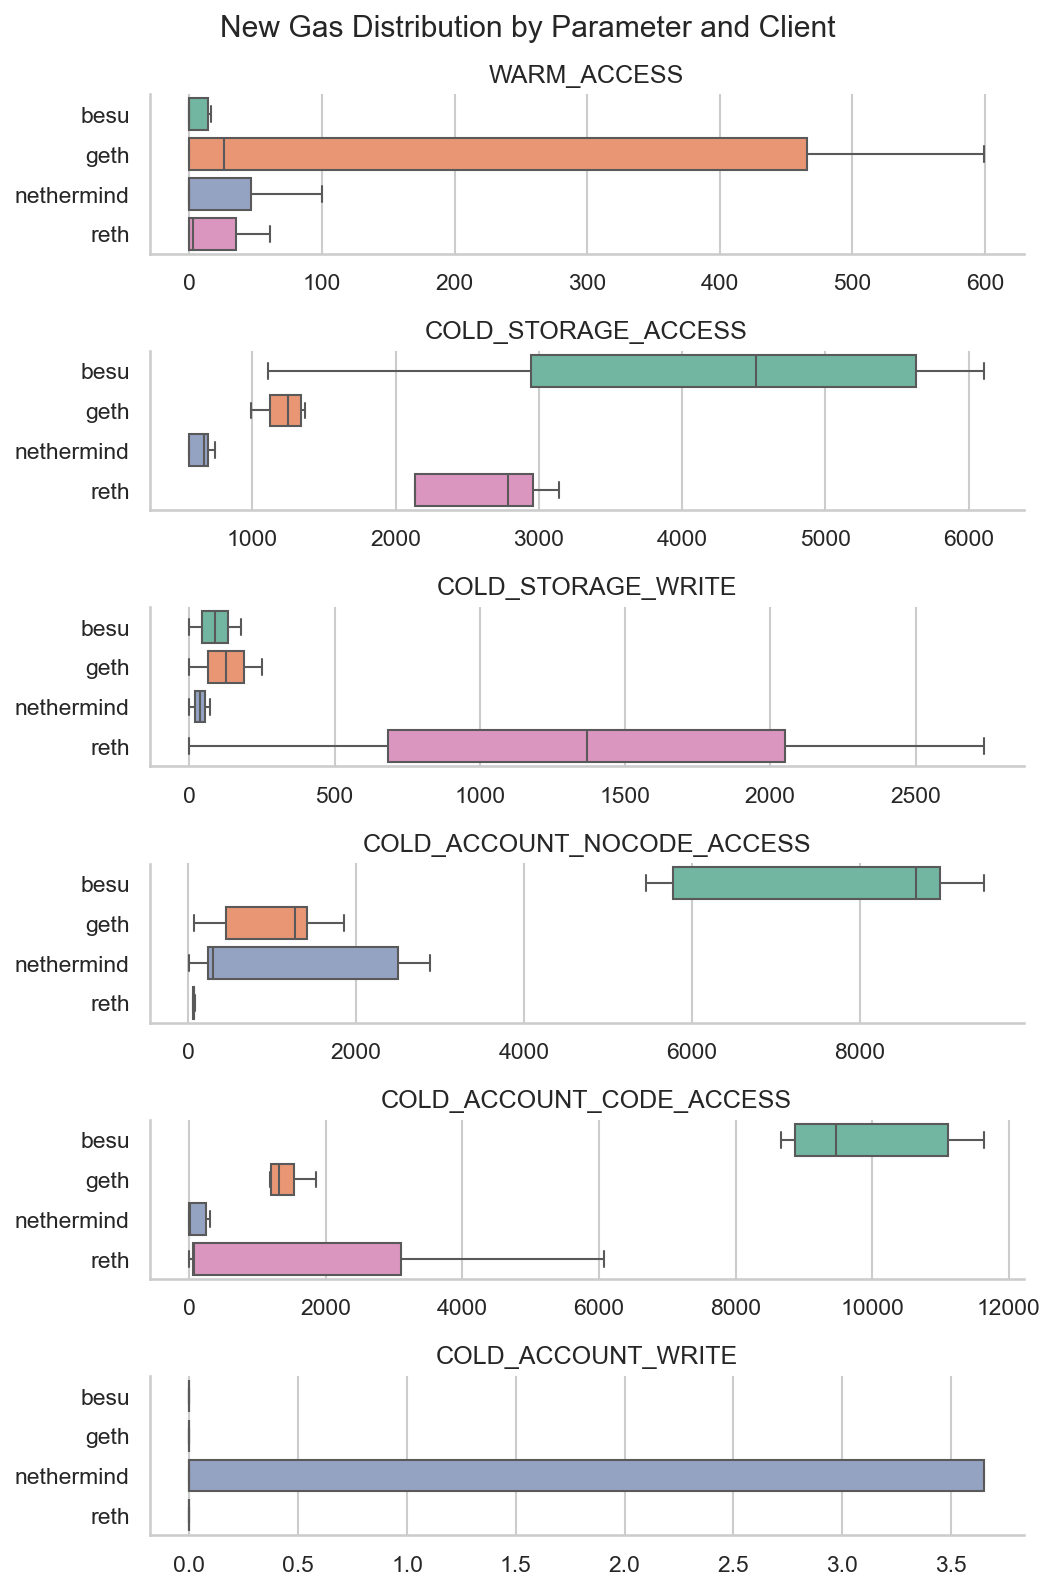

In [32]:
# Box plot: new_gas distribution per gas_param, colored by client
g = sns.catplot(
    data=df,
    y="client_name",
    x="new_gas",
    hue="client_name",
    row="gas_param_short",
    kind="box",
    order=clients,
    showfliers=False,
    height=1.8,
    aspect=4,
    sharex=False,
)
g.set_titles("{row_name}")
g.set_xlabels("")
g.set_ylabels("")
g.figure.suptitle("New Gas Distribution by Parameter and Client")
plt.tight_layout()
plt.show()

## 2. Impact of Test and Variants on Each Gas Parameter

For each gas parameter, break down new gas by test, cache strategy, account mode, and existing slots.

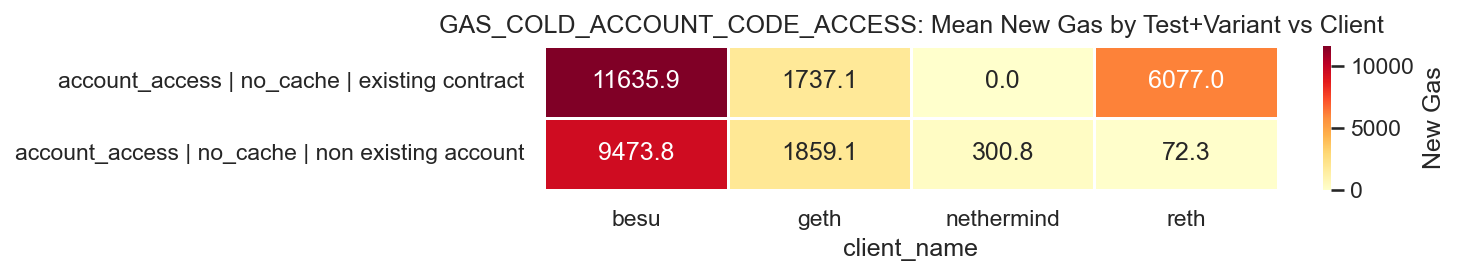

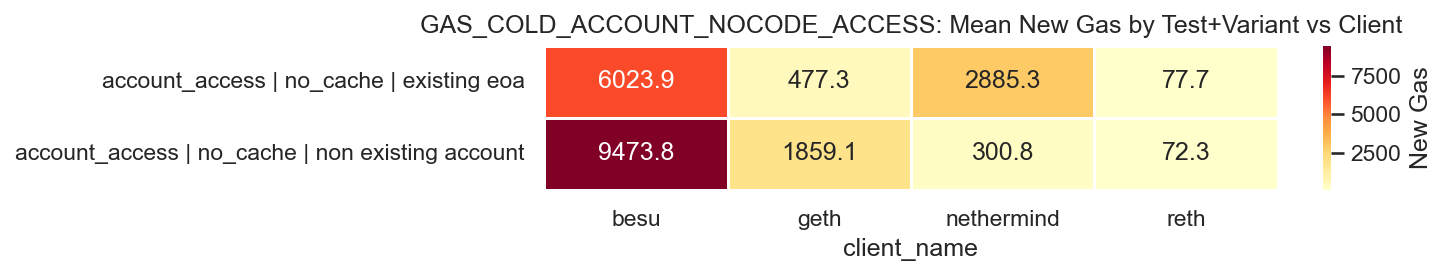

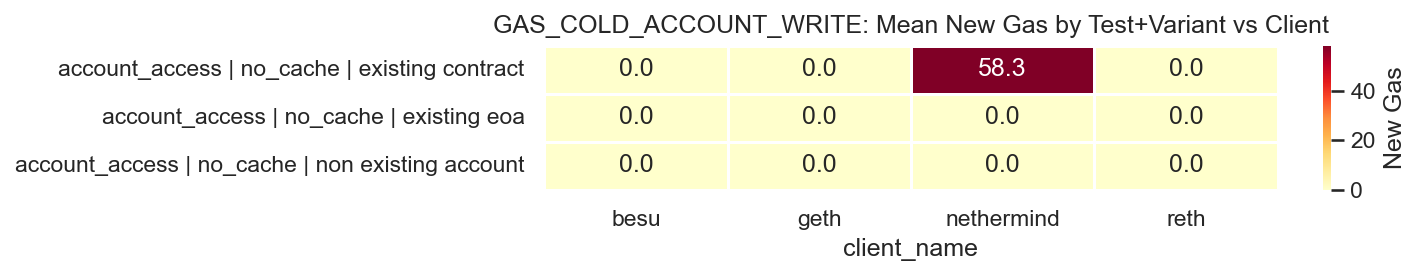

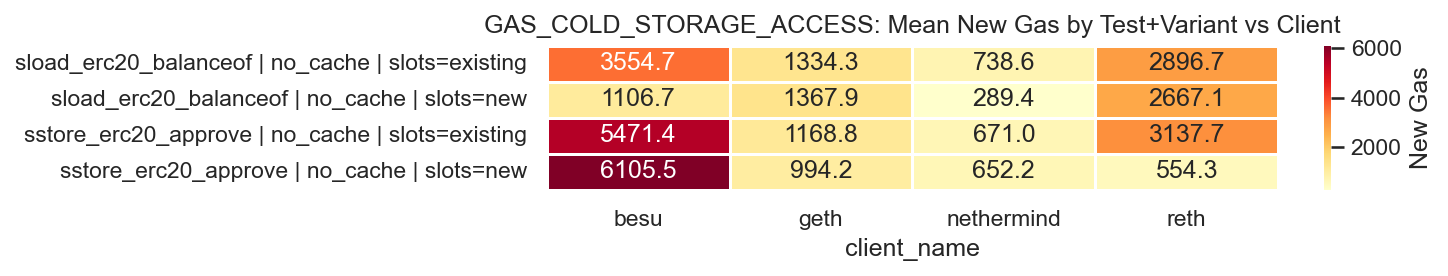

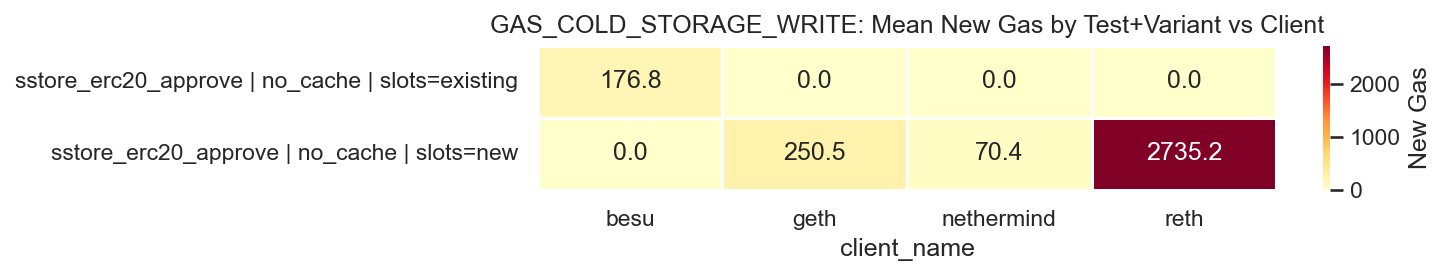

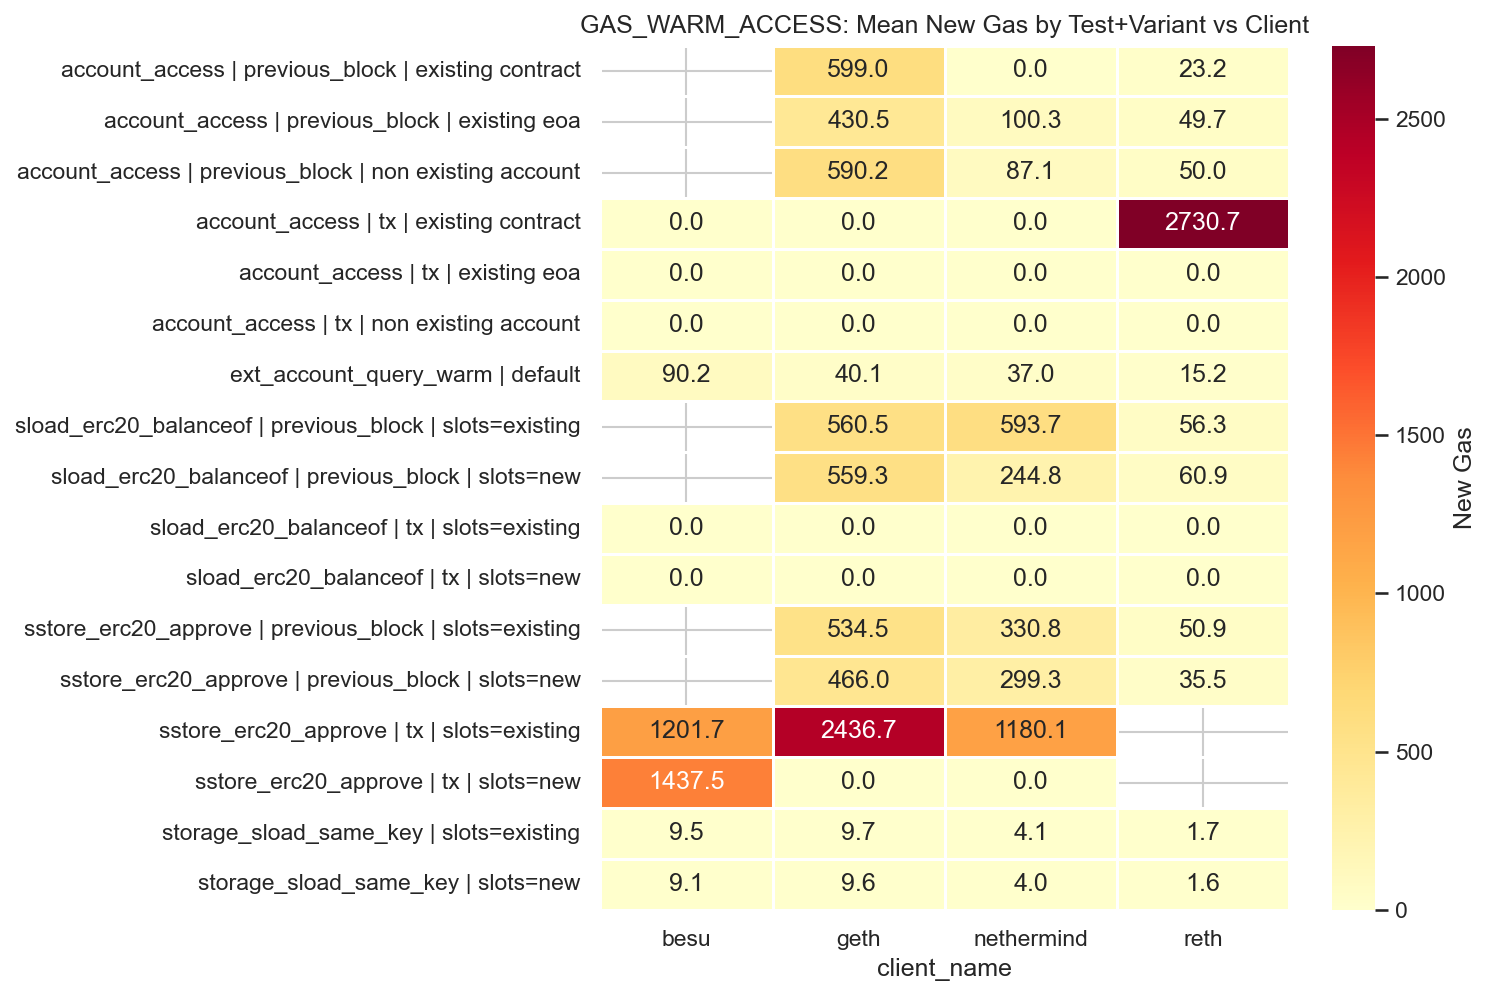

In [33]:
# Heatmap: mean new_gas by test+variant vs client, for each gas param
for gp in gas_params:
    gp_df = df[df["gas_param"] == gp].copy()
    gp_df["test_variant"] = gp_df["test_short"] + " | " + gp_df["variant"]
    pivot = gp_df.pivot_table(
        index="test_variant", columns="client_name", values="new_gas", aggfunc="max"
    )
    if pivot.empty:
        continue
    fig, ax = plt.subplots(figsize=(10, max(2, len(pivot) * 0.4)))
    sns.heatmap(
        pivot,
        ax=ax,
        cmap="YlOrRd",
        annot=True,
        fmt=".1f",
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "New Gas"},
    )
    ax.set_title(f"{gp}: Mean New Gas by Test+Variant vs Client", fontsize=12)
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

## 3. Impact of Cache Strategy

How does cache strategy (TX, PREVIOUS_BLOCK) affect GAS_WARM_ACCESS?

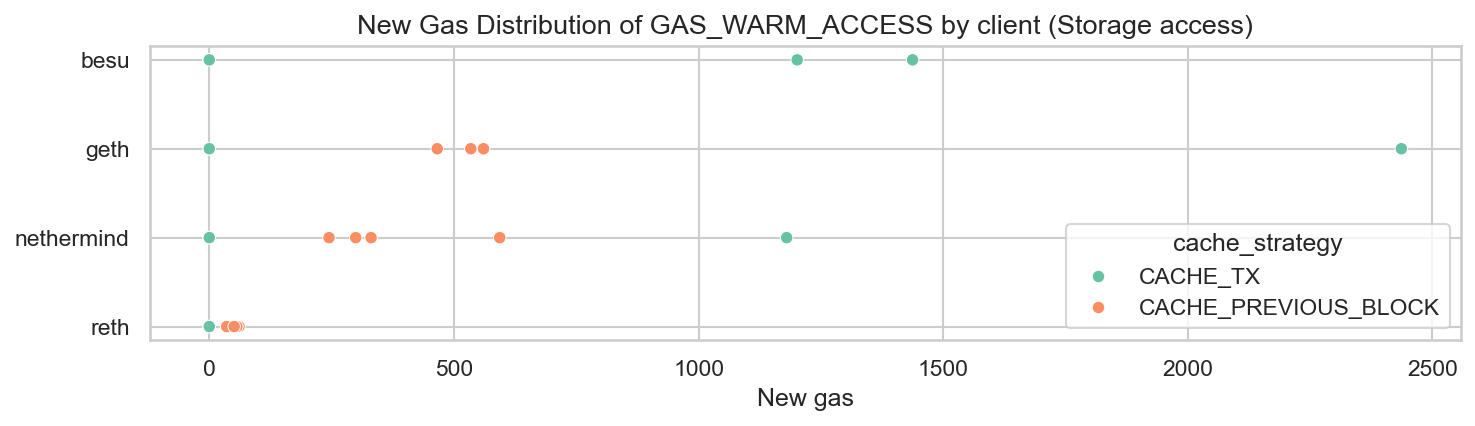

In [34]:
temp_df = df[
    (df["cache_strategy"] != "N/A")
    & (df["gas_param"] == "GAS_WARM_ACCESS")
    & (df["opcode"].isin(["SSTORE", "SLOAD"]))
]

plt.figure(figsize=(10, 3))
sns.scatterplot(
    data=temp_df, y="client_name", x="new_gas", hue="cache_strategy",
)
plt.xlabel("New gas")
plt.ylabel("")
plt.title("New Gas Distribution of GAS_WARM_ACCESS by client (Storage access)")
plt.tight_layout()
plt.show()

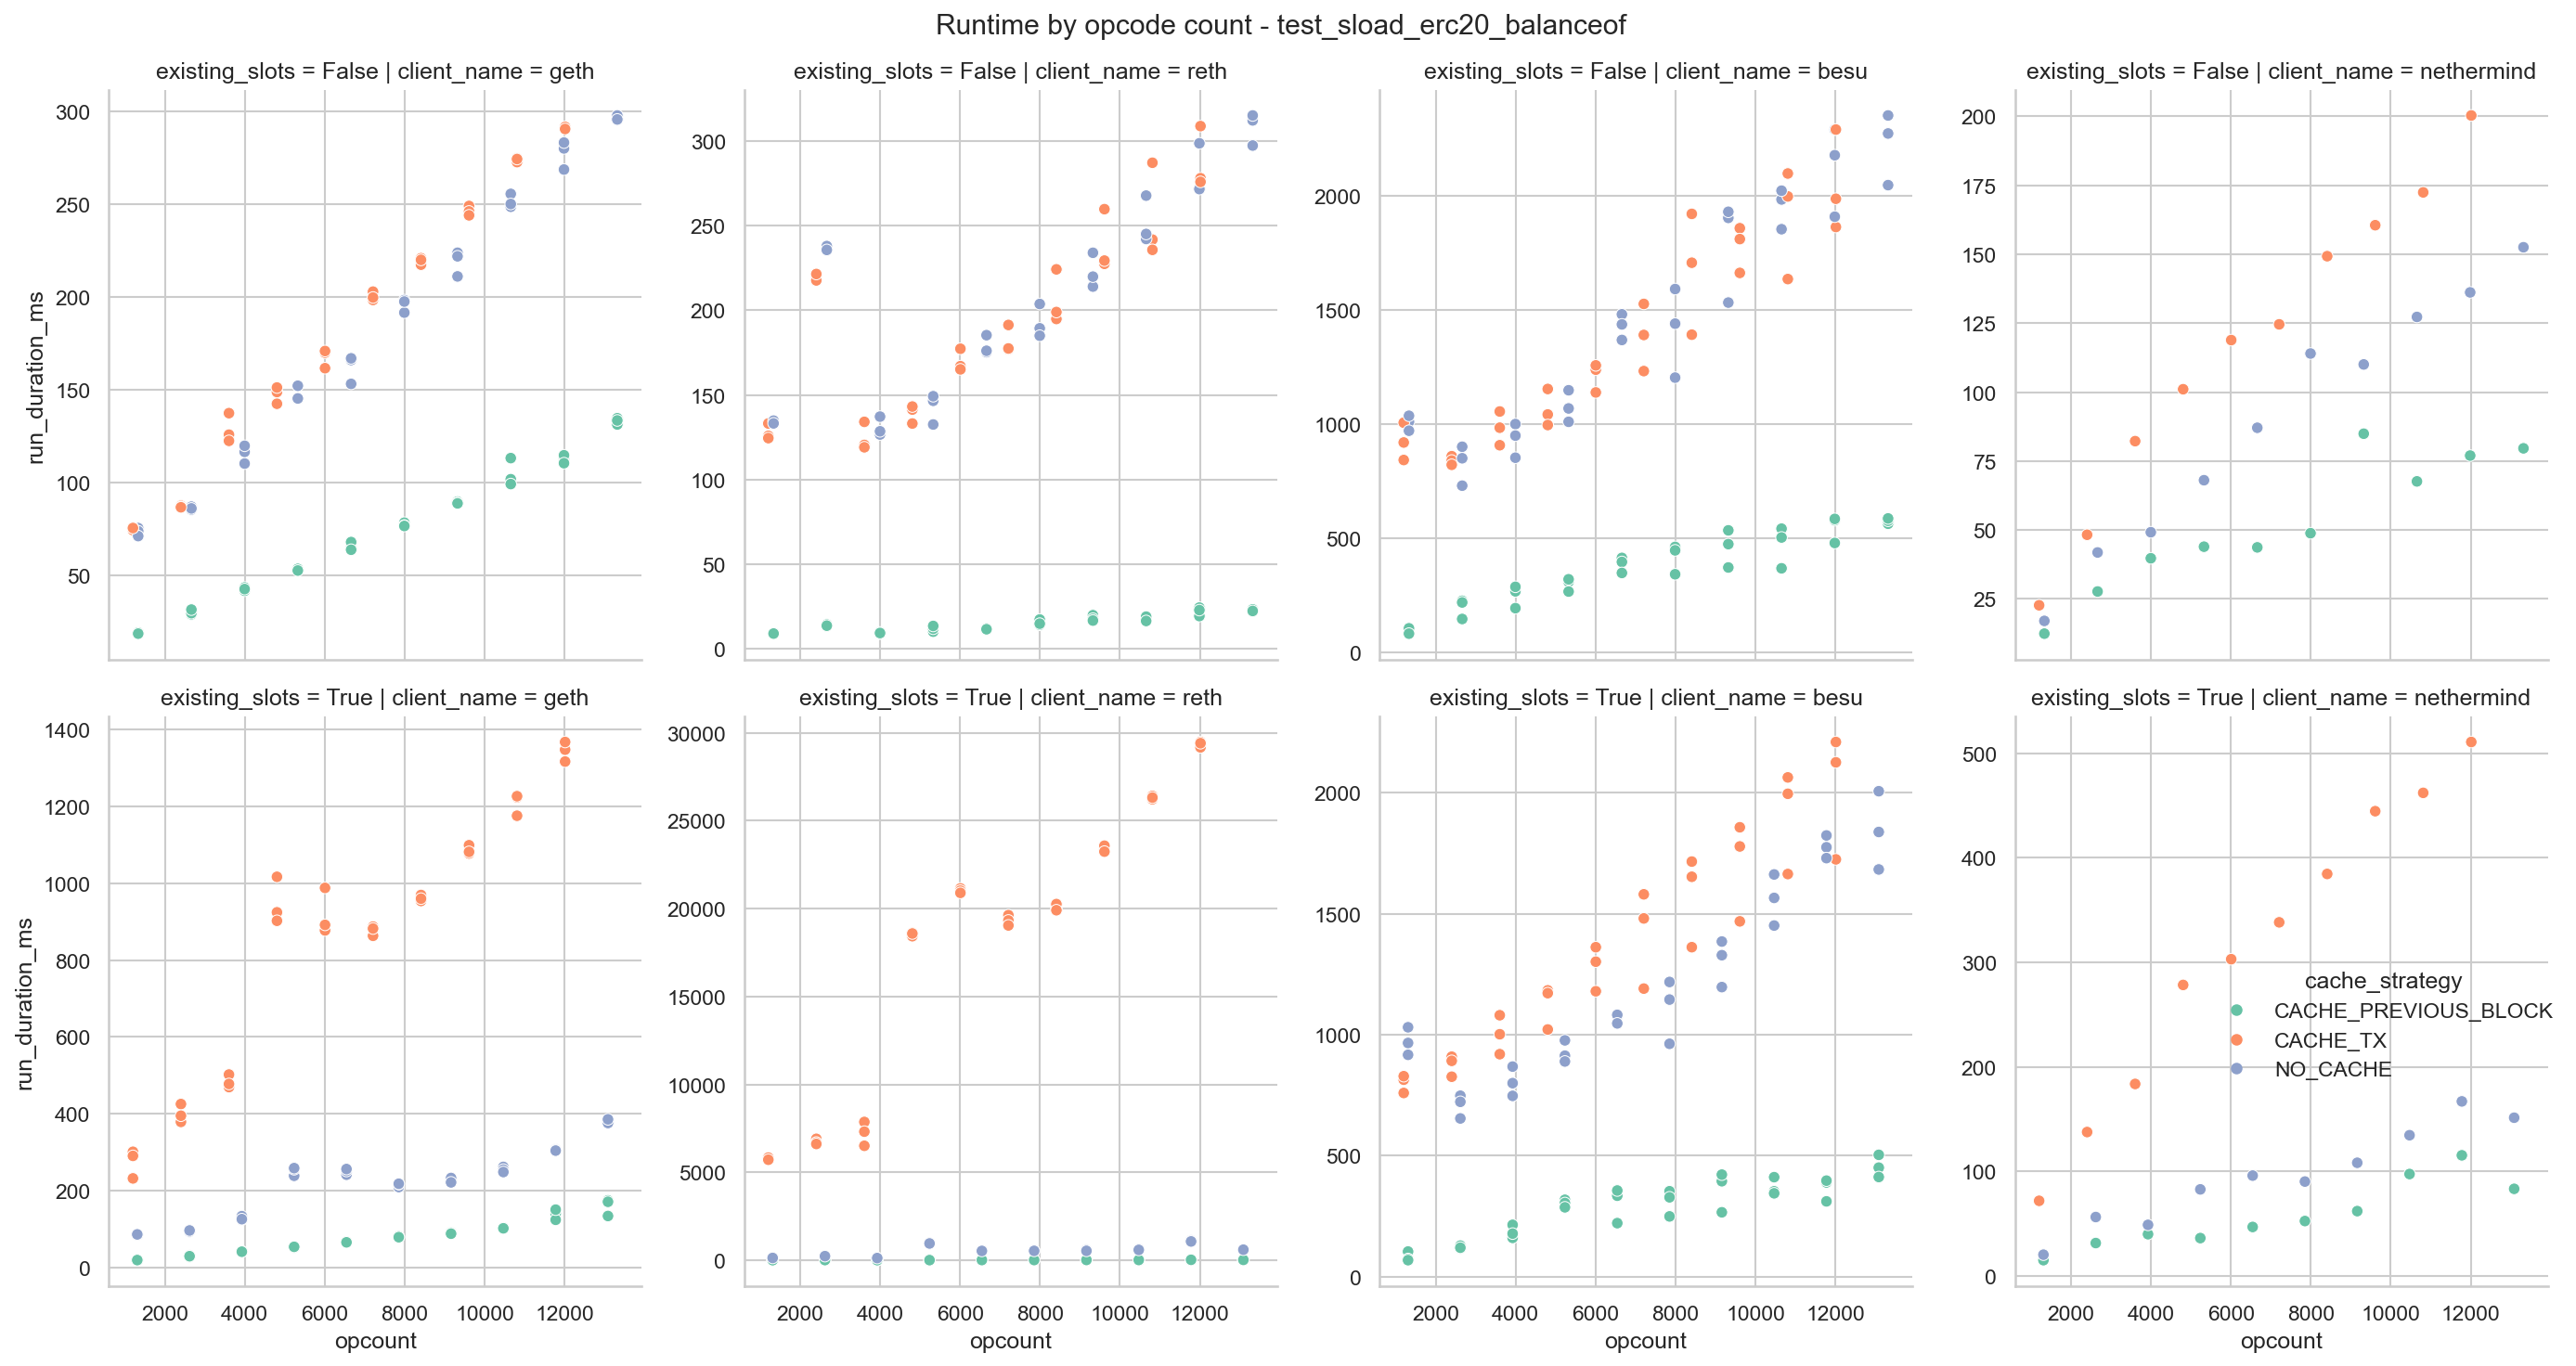

In [35]:
sload_df = gas_bench_df[
    (gas_bench_df["test_opcode"] == "SSTORE")
    & (gas_bench_df["test_name"] == "test_sstore_erc20_approve")
    & (gas_bench_df["test_params"] == "update_0")
]

g = sns.relplot(
    data=sload_df,
    x="opcount",
    y="run_duration_ms",
    hue="cache_strategy",
    col="client_name",
    row="existing_slots",
    facet_kws={"sharey": False},
    aspect=0.8,
)
sns.move_legend(g, "lower right", bbox_to_anchor=(1, 0.2))
plt.suptitle("Runtime by opcode count - test_sload_erc20_balanceof")
plt.tight_layout()
plt.show()

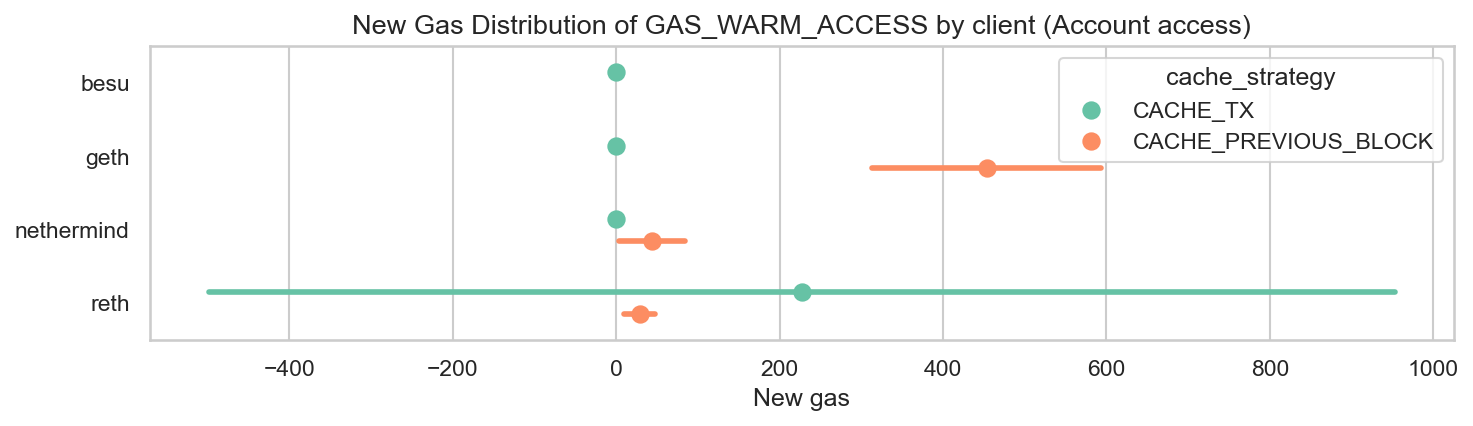

In [36]:
temp_df = df[
    (df["cache_strategy"] != "N/A")
    & (df["gas_param"] == "GAS_WARM_ACCESS")
    & (~df["opcode"].isin(["SSTORE", "SLOAD"]))
]

plt.figure(figsize=(10, 3))
sns.pointplot(
    data=temp_df, y="client_name", x="new_gas", hue="cache_strategy", errorbar="sd", join=False, dodge=0.3
)
plt.xlabel("New gas")
plt.ylabel("")
plt.title("New Gas Distribution of GAS_WARM_ACCESS by client (Account access)")
plt.tight_layout()
plt.show()

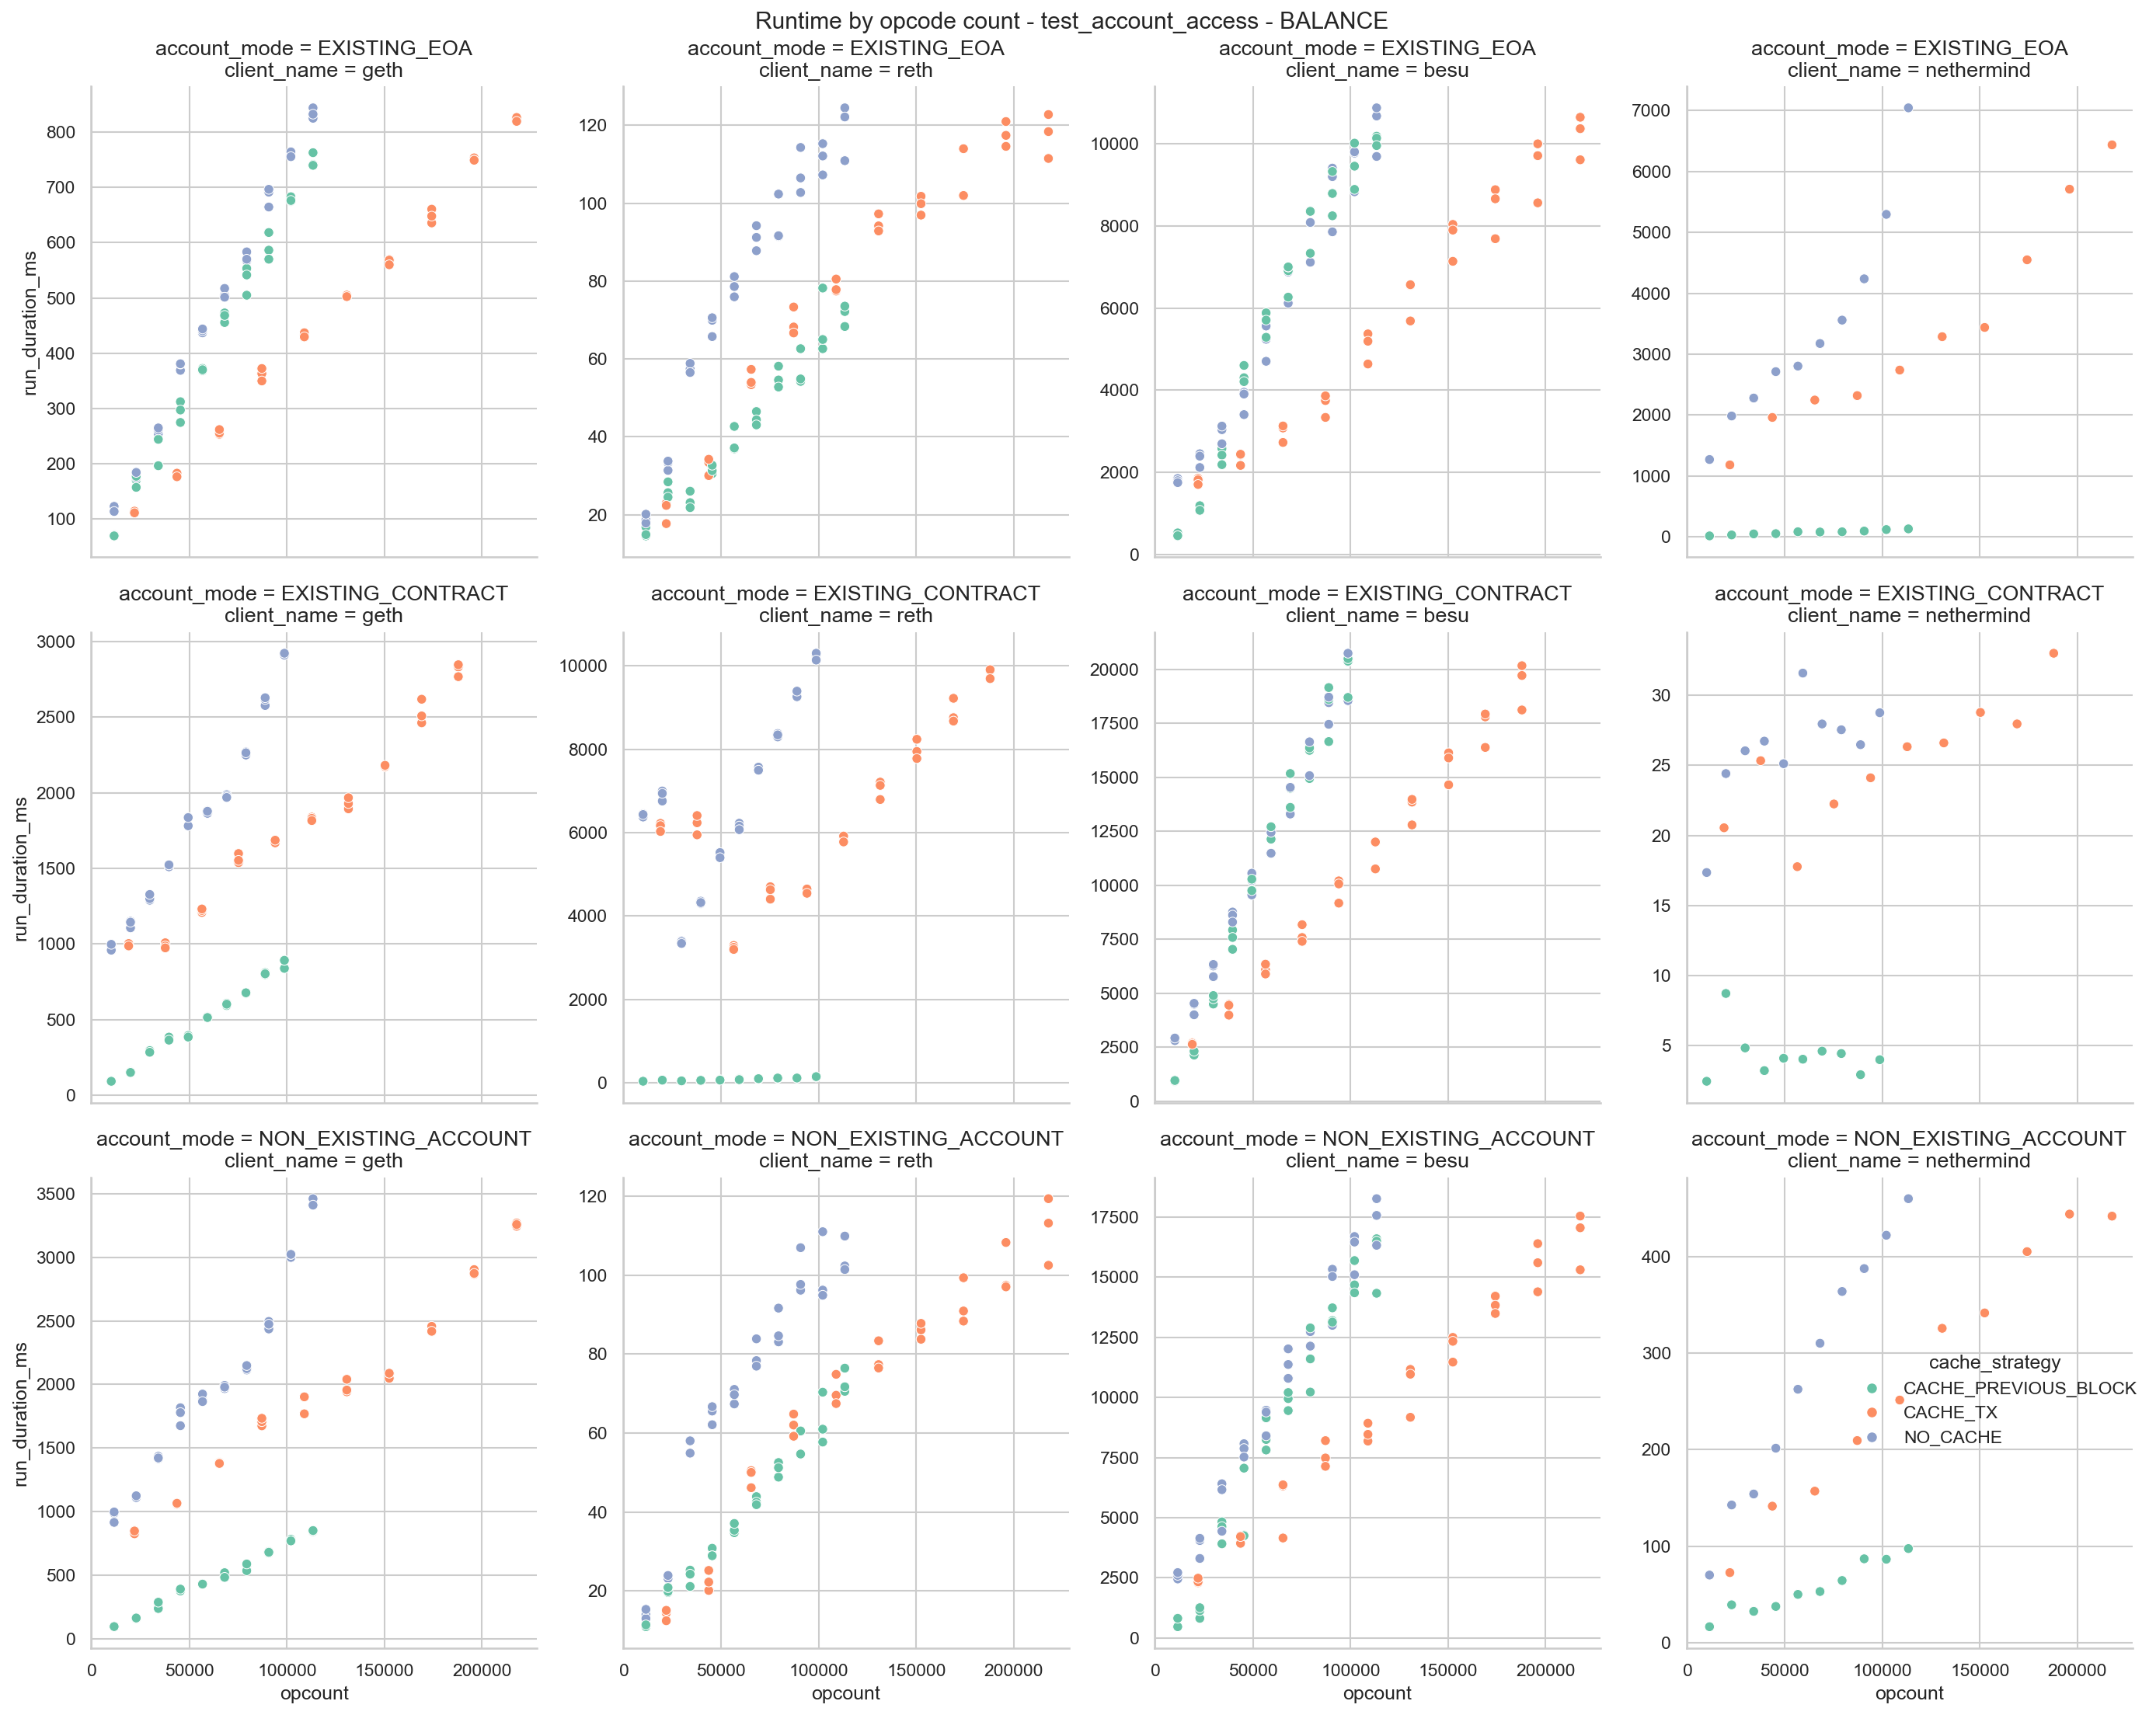

In [37]:
temp_df = gas_bench_df[
    (gas_bench_df["test_opcode"] == "BALANCE")
    & (gas_bench_df["test_name"] == "test_account_access")
]

g = sns.relplot(
    data=temp_df,
    x="opcount",
    y="run_duration_ms",
    hue="cache_strategy",
    col="client_name",
    row="account_mode",
    facet_kws={"sharey": False},
    aspect=0.8,
)
for ax in g.axes.flat:
    title = ax.get_title()
    ax.set_title(title.replace(" | ", "\n"))
sns.move_legend(g, "lower right", bbox_to_anchor=(1, 0.15))
plt.suptitle("Runtime by opcode count - test_account_access - BALANCE")
plt.tight_layout()
plt.show()

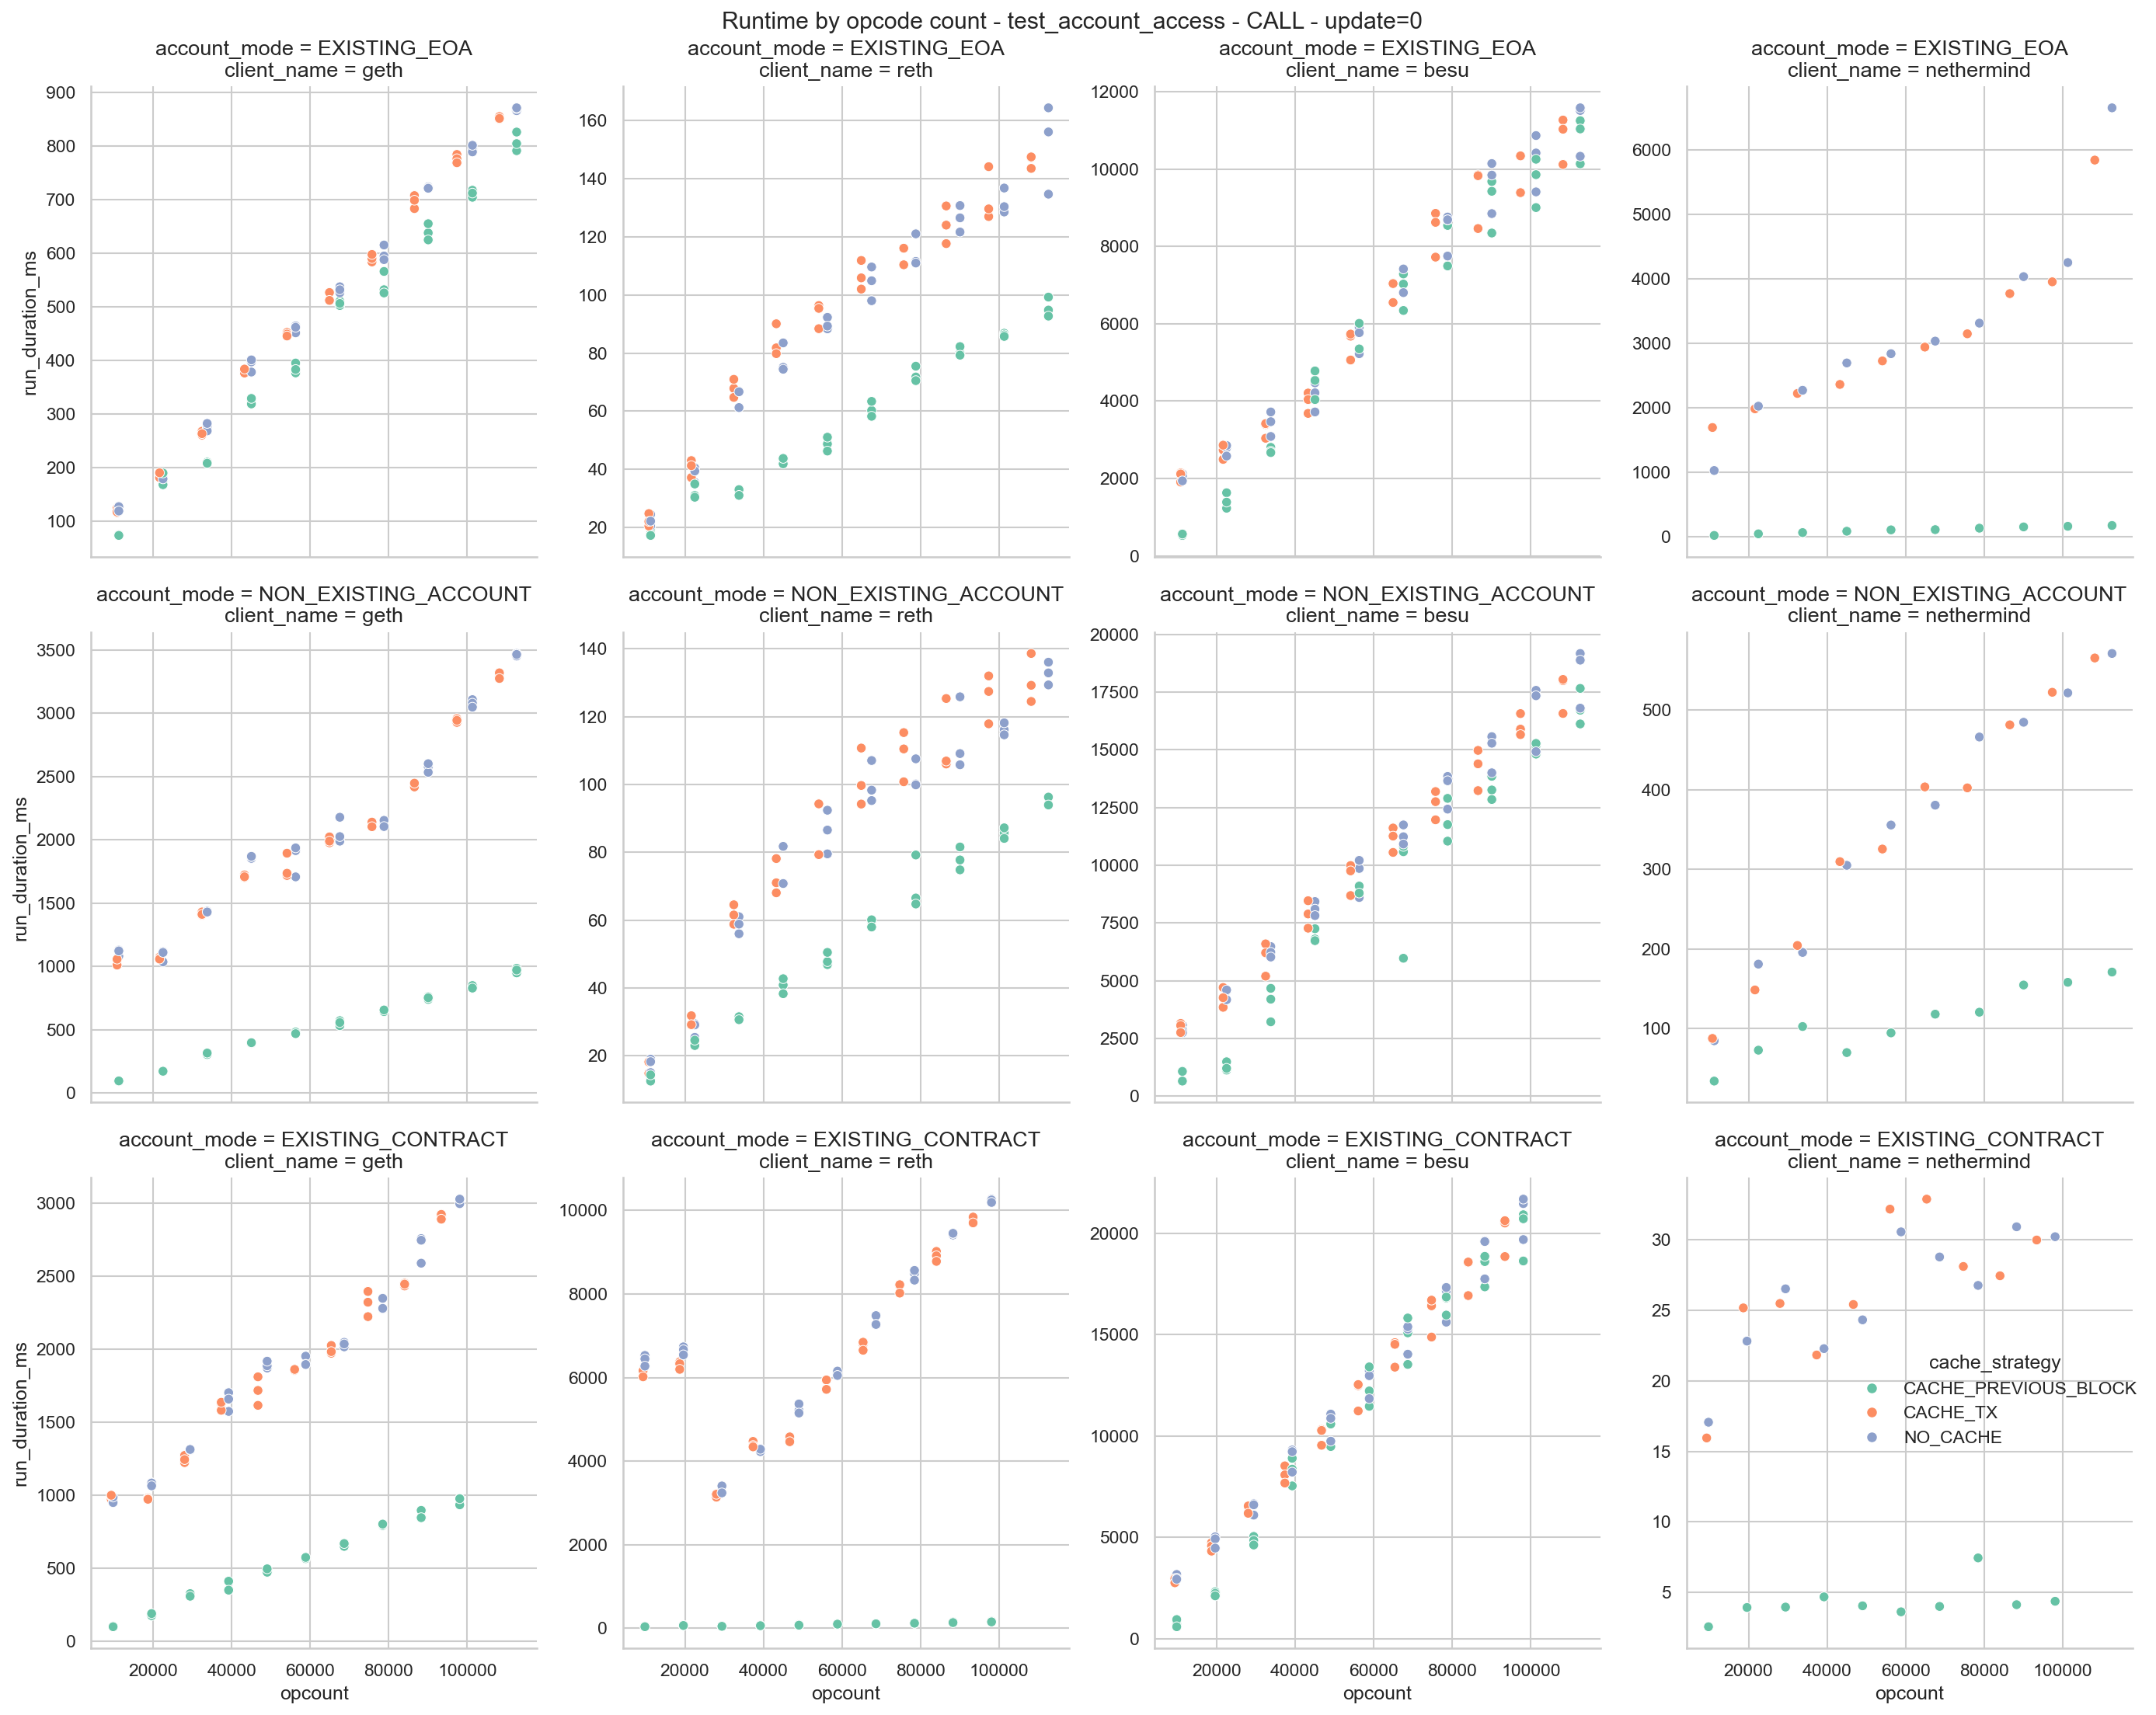

In [38]:
temp_df = gas_bench_df[
    (gas_bench_df["test_opcode"] == "CALL")
    & (gas_bench_df["test_params"] == "update_0")
    & (gas_bench_df["test_name"] == "test_account_access")
]

g = sns.relplot(
    data=temp_df,
    x="opcount",
    y="run_duration_ms",
    hue="cache_strategy",
    col="client_name",
    row="account_mode",
    facet_kws={"sharey": False},
    aspect=0.8,
)
for ax in g.axes.flat:
    title = ax.get_title()
    ax.set_title(title.replace(" | ", "\n"))
sns.move_legend(g, "lower right", bbox_to_anchor=(1, 0.15))
plt.suptitle("Runtime by opcode count - test_account_access - CALL - update=0")
plt.tight_layout()
plt.show()

The new gas for `CACHE_PREVIOUS_BLOCK` is almost always zero. This is due to the fact that runtime for `NO_CACHE` is higher or equal to `CACHE_TX`, which is weird. The variant `CACHE_TX` should have an additional warm `SLOAD` or `BALANCE` and this should always take more time to run.

## 4. Impact of Account Mode

How do existing contracts vs EOAs vs non-existing accounts affect cold access gas?

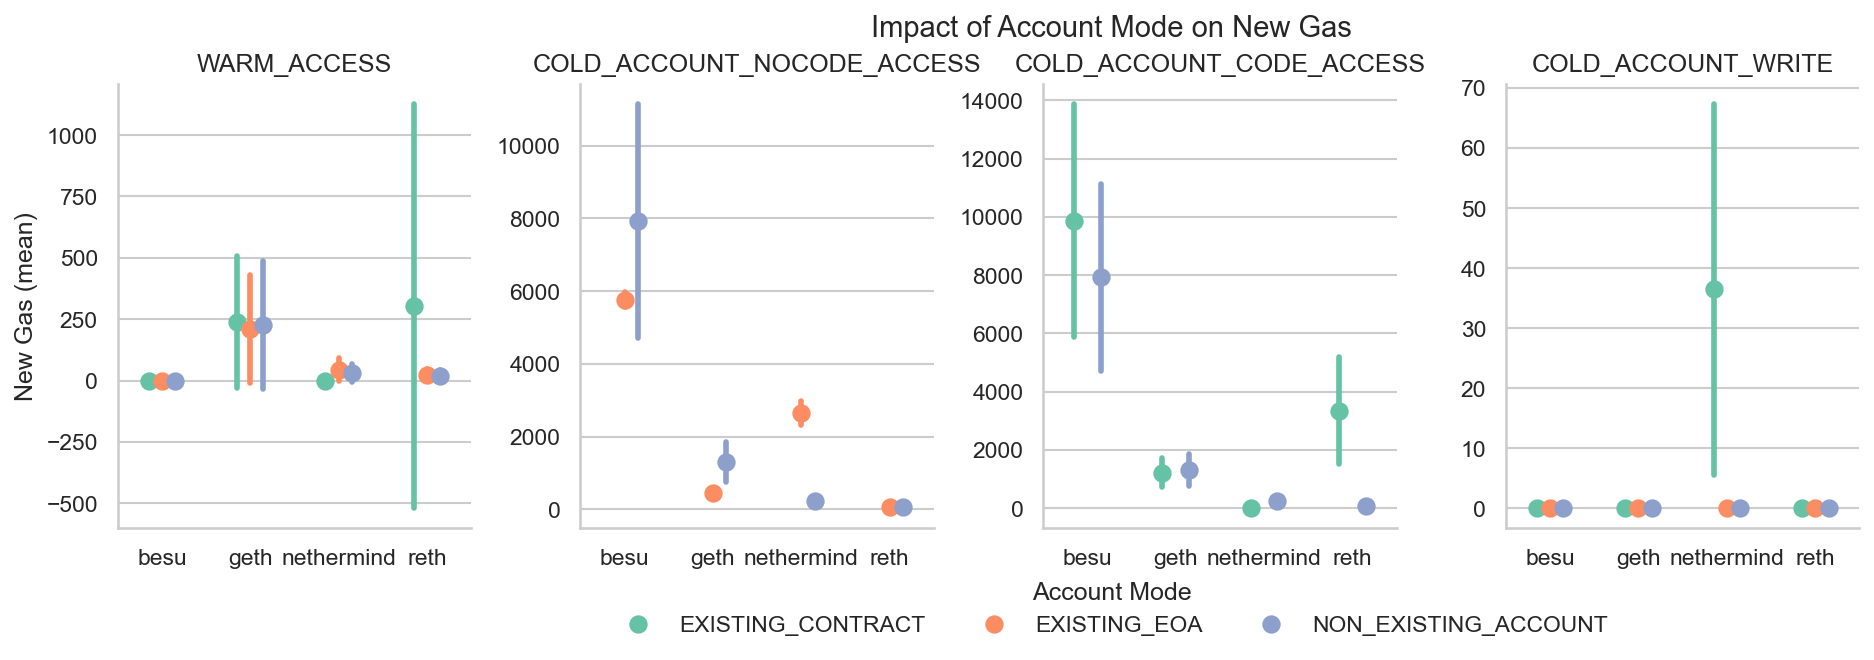

In [39]:
# Filter to rows with actual account mode values
acct_df = df[(df["account_mode"] != "N/A")]
acct_df["gas_param_short"] = acct_df["gas_param"].str.replace("GAS_", "")

g = sns.catplot(
    data=acct_df,
    x="client_name",
    y="new_gas",
    hue="account_mode",
    col="gas_param_short",
    kind="point",
    order=clients,
    errorbar="sd",
    height=4,
    aspect=0.8,
    sharey=False,
    join=False,
    dodge=0.3
)
g.set_titles("{col_name}", fontsize=11)
g.set_xlabels("")
g.set_ylabels("New Gas (mean)")
sns.move_legend(g, "lower center", bbox_to_anchor=(0.5, -0.05), ncol=3, title="Account Mode")
g.figure.suptitle("Impact of Account Mode on New Gas", fontsize=14, y=1.02)

plt.show()

As expected, different clients show different behaviors on the worst case for the account mode.

## 5. Impact of Existing Slots

Does accessing existing vs new storage slots change the gas estimation?

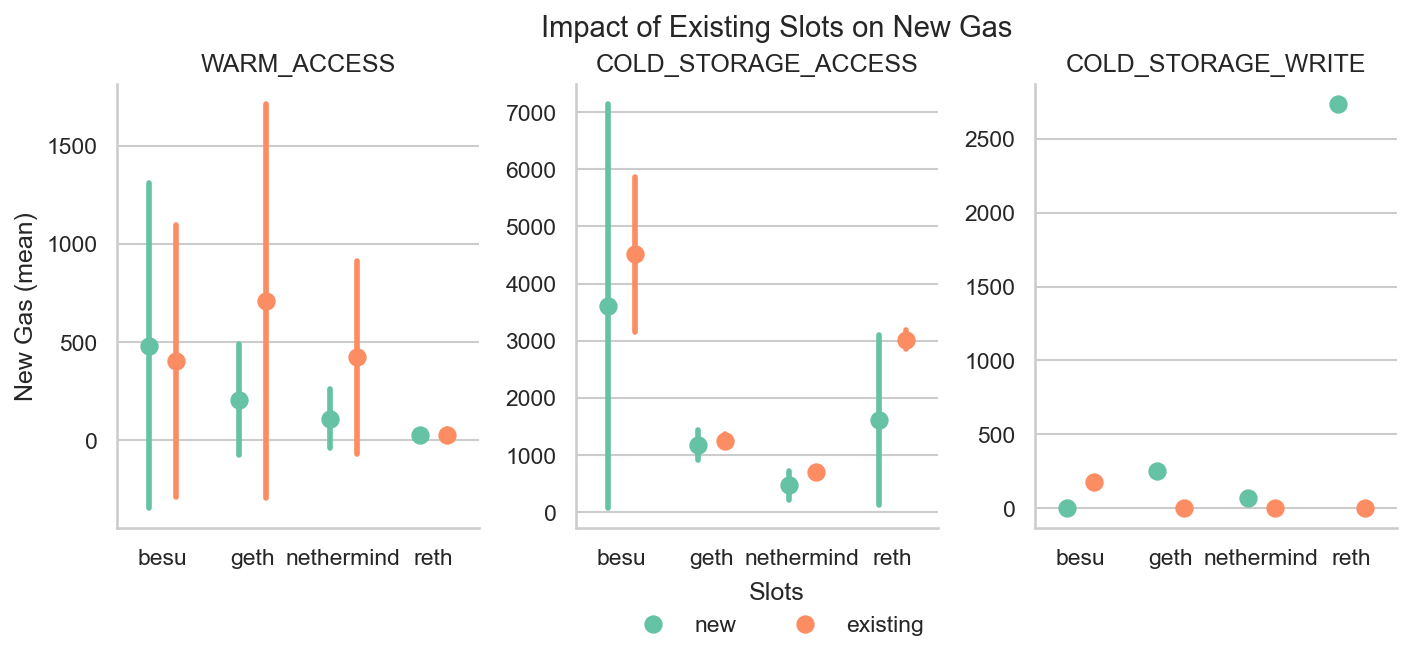

In [40]:
# Filter to rows with actual existing_slots values
slots_df = df[df["existing_slots"] != "N/A"].copy()
slots_df["gas_param_short"] = slots_df["gas_param"].str.replace("GAS_", "")

g = sns.catplot(
    data=slots_df,
    x="client_name",
    y="new_gas",
    hue="existing_slots",
    col="gas_param_short",
    kind="point",
    order=clients,
    errorbar="sd",
    height=4,
    aspect=0.8,
    sharey=False,
    join=False,
    dodge=0.3
)
g.set_titles("{col_name}", fontsize=11)
g.set_xlabels("")
g.set_ylabels("New Gas (mean)")
sns.move_legend(g, "lower center", bbox_to_anchor=(0.5, -0.05), ncol=3, title="Slots")
g.figure.suptitle("Impact of Existing Slots on New Gas", fontsize=14, y=1.02)
plt.show()

Strangely, for `test_sload_erc20_balanceof`, the existing slot variant always takes longer to run, which is not consistent with our expectation. For instance, we would expect geth to take longer in the non-existing variant.

## 6. Writing surcharge

Does the `update_1` variant take longer to run? We expect it should as there should be more work on state root calculation and DB writes.

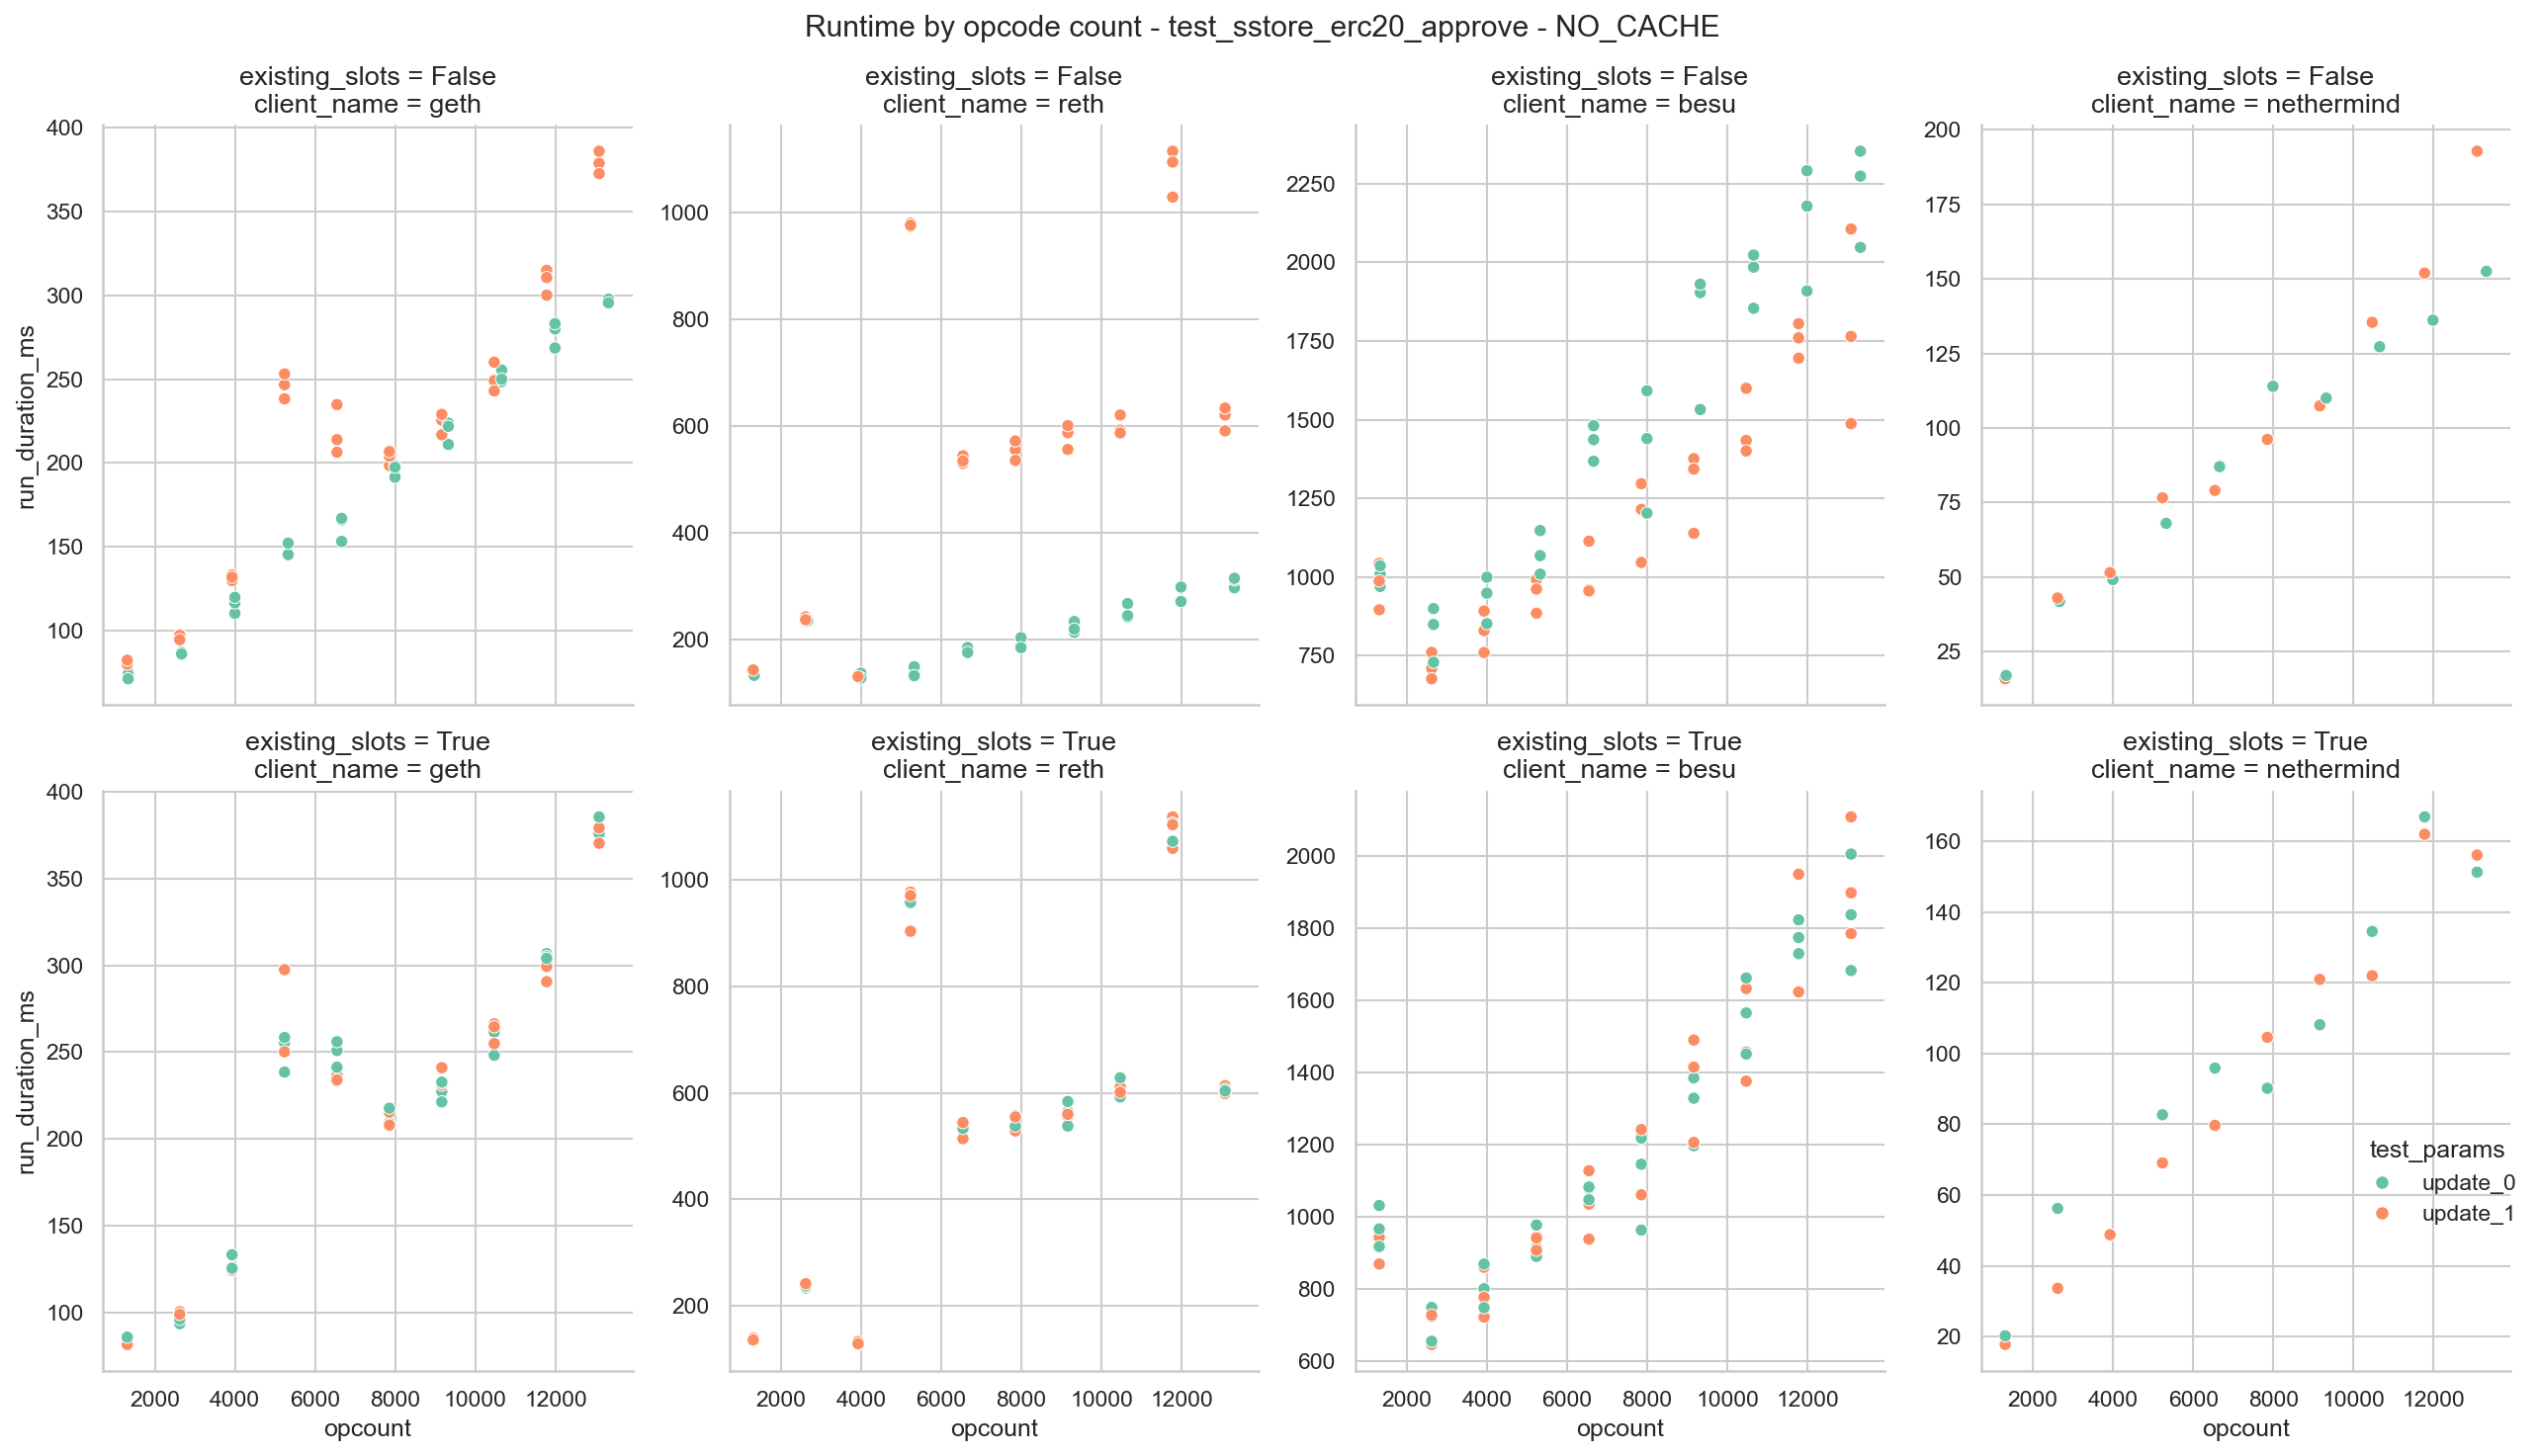

In [41]:
temp_df = gas_bench_df[
    (gas_bench_df["test_name"] == "test_sstore_erc20_approve")
    & (gas_bench_df["cache_strategy"] == "NO_CACHE")
]

g = sns.relplot(
    data=temp_df,
    x="opcount",
    y="run_duration_ms",
    hue="test_params",
    col="client_name",
    row="existing_slots",
    facet_kws={"sharey": False},
    aspect=0.8,
)
for ax in g.axes.flat:
    title = ax.get_title()
    ax.set_title(title.replace(" | ", "\n"))
sns.move_legend(g, "lower right", bbox_to_anchor=(1, 0.15))
plt.suptitle("Runtime by opcode count - test_sstore_erc20_approve - NO_CACHE")
plt.tight_layout()
plt.show()

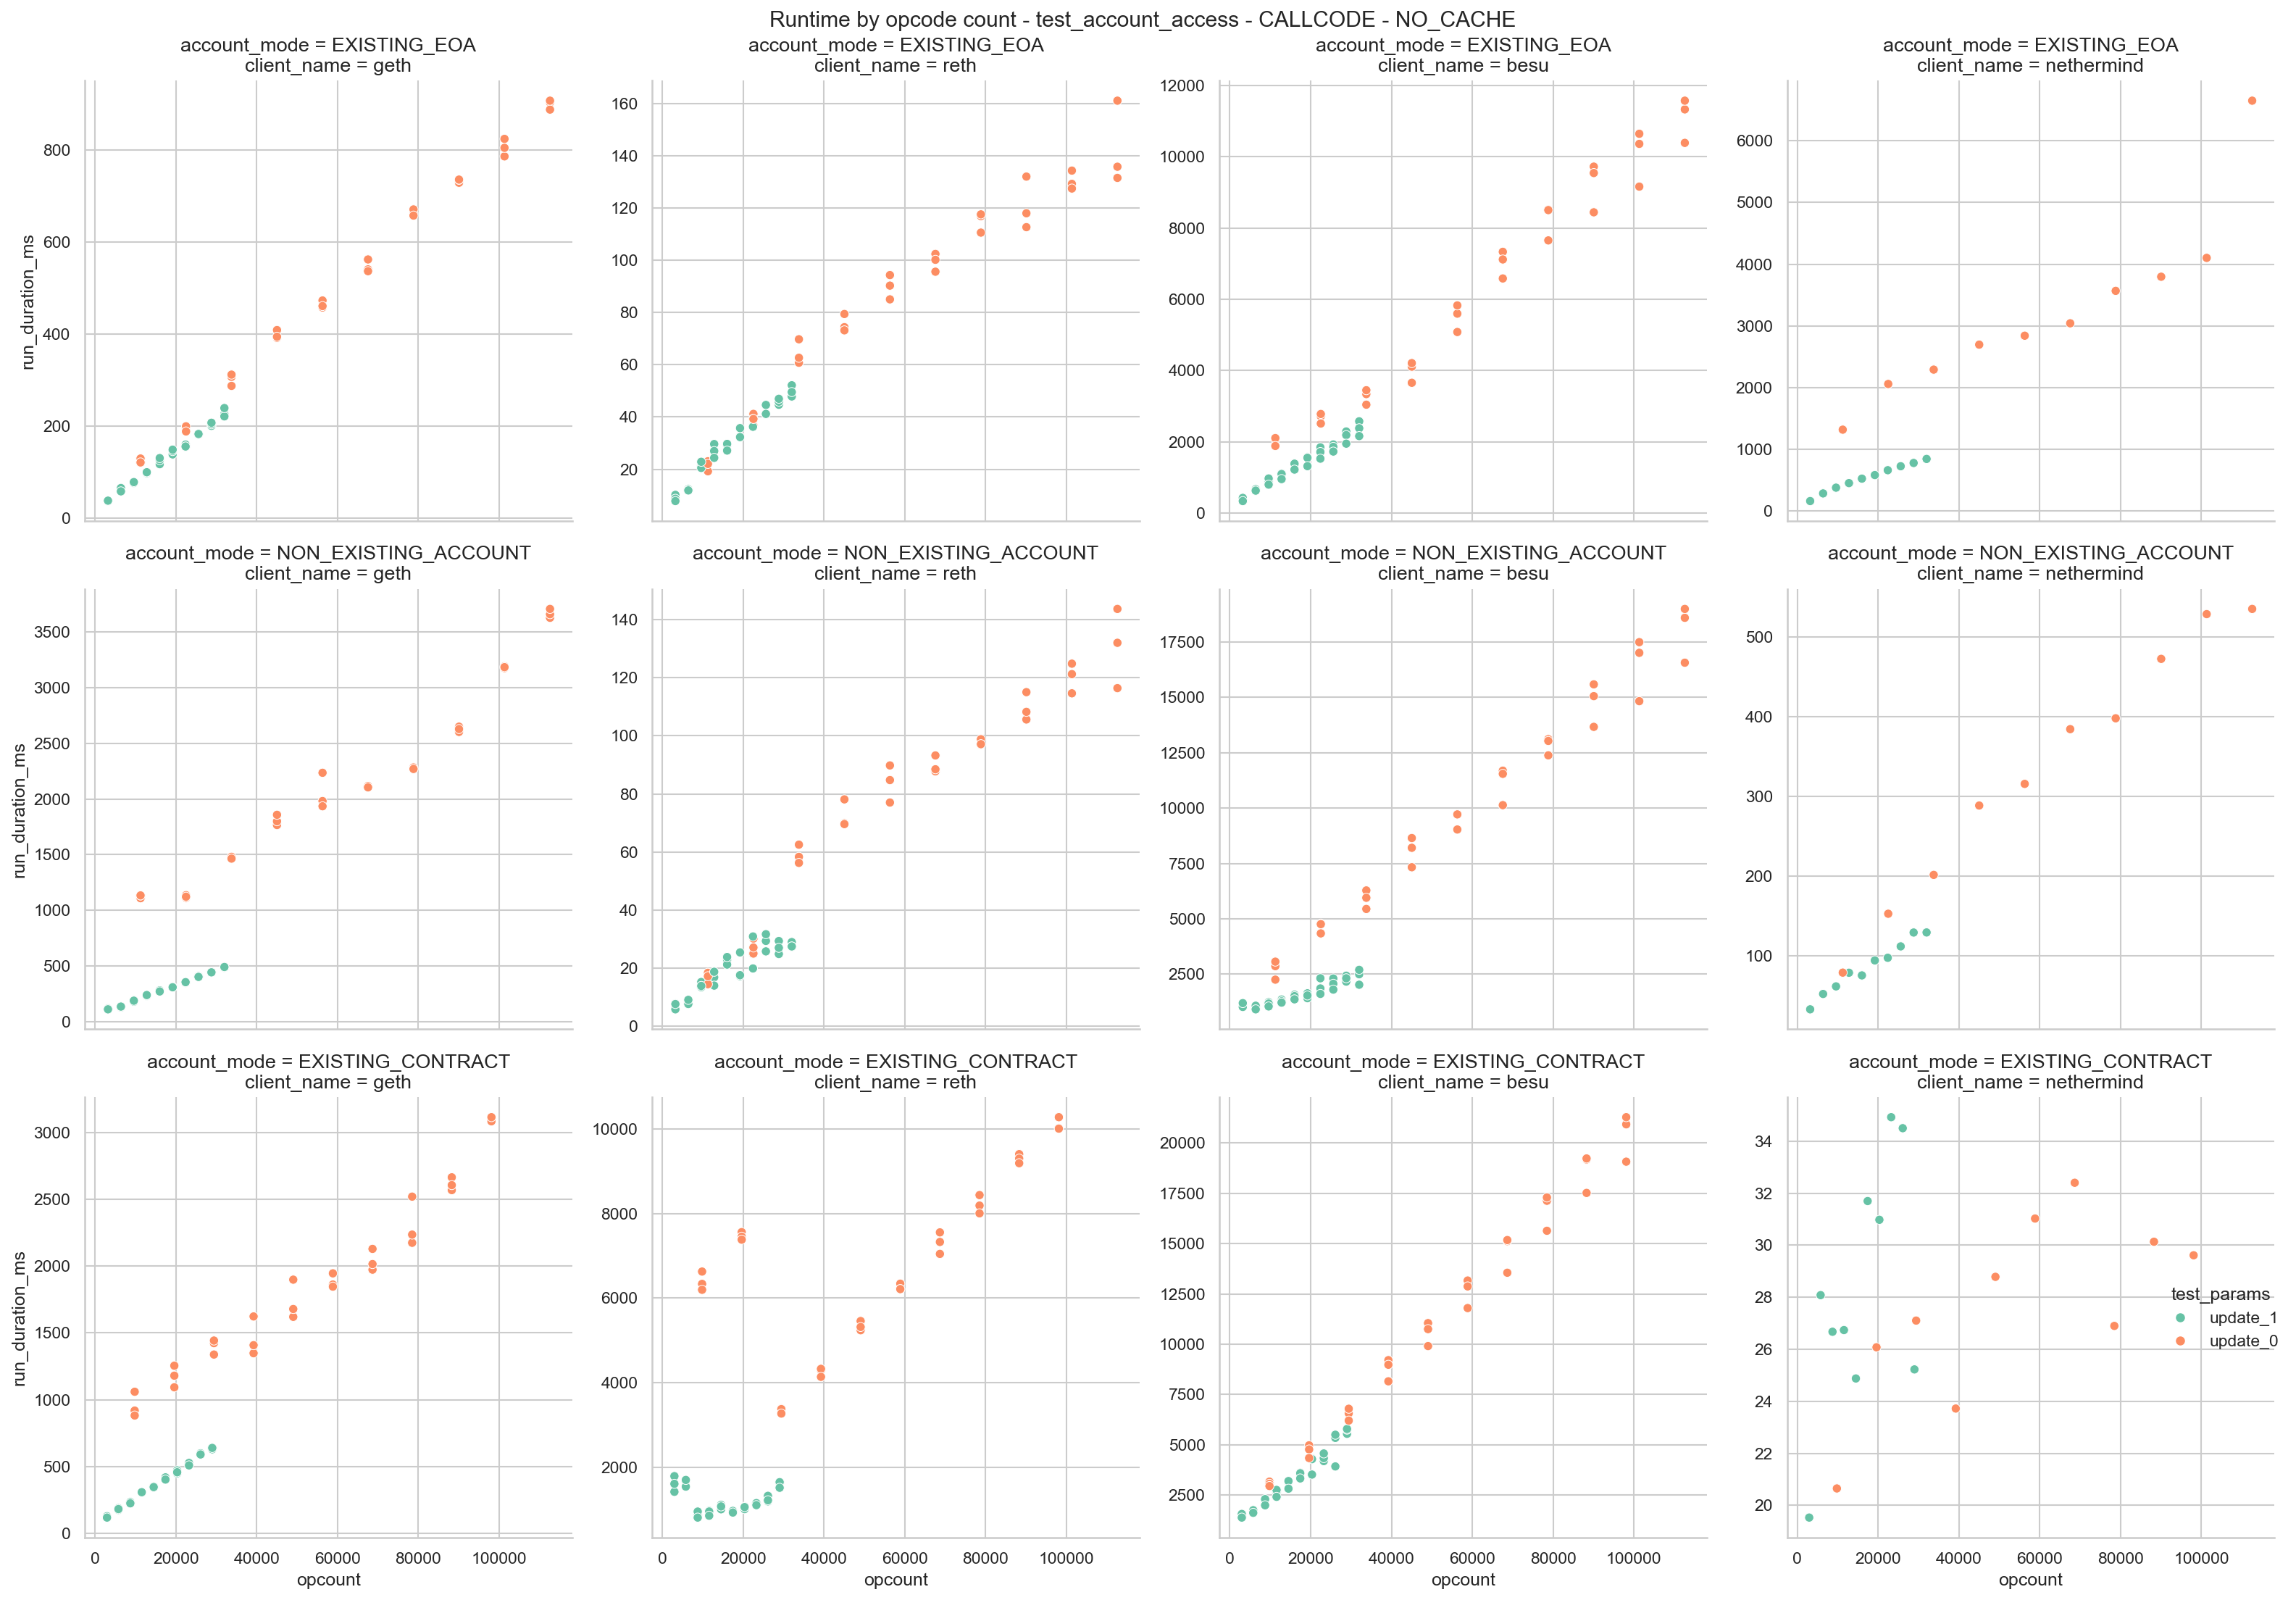

In [42]:
temp_df = gas_bench_df[
    (gas_bench_df["test_name"] == "test_account_access")
    & (gas_bench_df["cache_strategy"] == "NO_CACHE")
    & (gas_bench_df["test_opcode"] == "CALLCODE")
]

g = sns.relplot(
    data=temp_df,
    x="opcount",
    y="run_duration_ms",
    hue="test_params",
    col="client_name",
    row="account_mode",
    facet_kws={"sharey": False},
    aspect=1,
)
for ax in g.axes.flat:
    title = ax.get_title()
    ax.set_title(title.replace(" | ", "\n"))
sns.move_legend(g, "lower right", bbox_to_anchor=(1, 0.15))
plt.suptitle("Runtime by opcode count - test_account_access - CALLCODE - NO_CACHE")
plt.tight_layout()
plt.show()

In [43]:
group_cols = ["test_opcode", "client_name", "test_params", "account_mode"]
results_list = []
filtered_df = gas_bench_df[
    (gas_bench_df["test_name"] == "test_account_access")
    & (gas_bench_df["cache_strategy"] == "NO_CACHE")
]
for group_values, group_df in filtered_df.groupby(group_cols, dropna=False):
    opcode, client, update, account_mode = group_values
    features = ["opcount"]
    model_df = group_df.copy()
    try:
        result = fit_NNLS_without_low_diff_runs(model_df, features)
    except Exception as e:
        print(f"FAILED: {opcode} {client} {update} {account_mode}: {e}")
        continue
    row = {
        "test_opcode": opcode,
        "client_name": client,
        "update": update,
        "account_mode": account_mode,
        "nobs": result.nobs,
        "rsquared": result.rsquared,
        "rsquared_adj": result.rsquared_adj,
        "intercept": result.params["const"],
        "intercept_pvalue": result.pvalues["const"],
        "slope": result.params["opcount"],
        "slope_pvalue": result.pvalues["opcount"],
        "slope_conf_int_low": result.conf_int().loc["opcount", 0],
        "slope_conf_int_high": result.conf_int().loc["opcount", 1],
    }
    results_list.append(row)
results_df = pd.DataFrame(results_list)
print(f"Fitted {len(results_df)} models")
results_df.head()

Fitted 108 models


,test_opcode,client_name,update,account_mode,nobs,rsquared,rsquared_adj,intercept,intercept_pvalue,slope,slope_pvalue,slope_conf_int_low,slope_conf_int_high
0,BALANCE,besu,update_0,EXISTING_CONTRACT,30,0.990410,0.990067,620.854005,0.001,0.195735,0.0,0.187486,0.203310
1,BALANCE,besu,update_0,EXISTING_EOA,30,0.969100,0.967996,227.102288,0.159,0.091320,0.0,0.085997,0.096073
2,BALANCE,besu,update_0,NON_EXISTING_ACCOUNT,30,0.981918,0.981273,775.322284,0.000,0.149305,0.0,0.142057,0.156836
3,BALANCE,geth,update_0,EXISTING_CONTRACT,30,0.977131,0.976314,707.636891,0.000,0.020853,0.0,0.019364,0.021904
4,BALANCE,geth,update_0,EXISTING_EOA,30,0.996321,0.996189,30.965177,0.000,0.007099,0.0,0.006970,0.007238


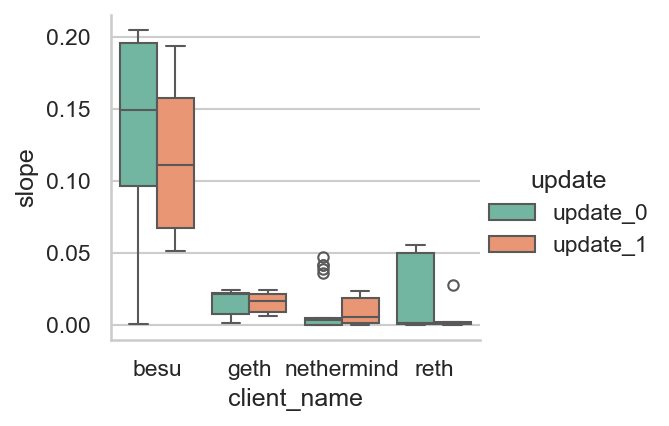

In [44]:
g = sns.catplot(
    data=results_df,
    x="client_name",
    y="slope",
    hue="update",
    kind="box",
    order=clients,
    height=3,
    aspect=1.2,
    sharey=False,

)

In [45]:
pivot = results_df.pivot_table(
    index=["test_opcode", "client_name", "account_mode"],
    columns="update",
    values=["slope", "rsquared", "slope_pvalue"],
).dropna()
pivot.columns = ["_".join(col) for col in pivot.columns]
pivot["slope_diff"] = pivot["slope_update_1"] - pivot["slope_update_0"]

In [46]:
pivot[pivot["slope_diff"]<=0].reset_index()

,test_opcode,client_name,account_mode,rsquared_update_0,rsquared_update_1,slope_update_0,slope_update_1,slope_pvalue_update_0,slope_pvalue_update_1,slope_diff
0,CALL,besu,EXISTING_CONTRACT,0.988325,0.966430,0.205150,0.193546,0.0,0.0,-0.011604
1,CALL,besu,EXISTING_EOA,0.971813,0.973221,0.096722,0.070027,0.0,0.0,-0.026695
2,CALL,besu,NON_EXISTING_ACCOUNT,0.982940,0.775534,0.153205,0.152358,0.0,0.0,-0.000847
3,CALL,geth,EXISTING_EOA,0.996151,0.989433,0.007481,0.007284,0.0,0.0,-0.000197
4,CALL,geth,NON_EXISTING_ACCOUNT,0.943720,0.992629,0.022519,0.022032,0.0,0.0,-0.000488
5,CALL,nethermind,EXISTING_EOA,0.852945,0.990638,0.041479,0.023330,0.0,0.0,-0.018149
6,CALL,reth,EXISTING_CONTRACT,0.561974,0.858474,0.055336,0.027670,0.0,0.0,-0.027665
7,CALLCODE,besu,EXISTING_CONTRACT,0.988274,0.951135,0.200536,0.159530,0.0,0.0,-0.041006
8,CALLCODE,besu,EXISTING_EOA,0.973030,0.969661,0.095439,0.066544,0.0,0.0,-0.028895
9,CALLCODE,besu,NON_EXISTING_ACCOUNT,0.981102,0.860038,0.151352,0.051759,0.0,0.0,-0.099593


In [47]:
pivot[pivot["slope_diff"]>0].reset_index()

,test_opcode,client_name,account_mode,rsquared_update_0,rsquared_update_1,slope_update_0,slope_update_1,slope_pvalue_update_0,slope_pvalue_update_1,slope_diff
0,CALL,geth,EXISTING_CONTRACT,0.970942,0.996523,0.022150,0.024585,0.000,0.000,0.002435
1,CALL,nethermind,EXISTING_CONTRACT,0.695019,0.539832,0.000125,0.000897,0.003,0.012,0.000773
2,CALL,nethermind,NON_EXISTING_ACCOUNT,0.977335,0.960042,0.004692,0.007692,0.000,0.000,0.003000
3,CALL,reth,EXISTING_EOA,0.964242,0.962904,0.001212,0.001542,0.000,0.000,0.000330
4,CALL,reth,NON_EXISTING_ACCOUNT,0.931985,0.949713,0.001092,0.001916,0.000,0.000,0.000824
5,CALLCODE,nethermind,EXISTING_CONTRACT,0.498172,0.365662,0.000084,0.000328,0.003,0.035,0.000244
6,CALLCODE,reth,EXISTING_EOA,0.955168,0.973876,0.001153,0.001410,0.000,0.000,0.000257
